In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, spearmanr
import warnings

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [30]:
!pip install -q ydata-profiling

In [40]:
# ==========================================
# 1. DATA LOADING
# ==========================================
# Note: Ensure these CSV files are in the same directory as the script.
global_df = pd.read_csv('Dataset_1.csv')
receiver_df = pd.read_csv('Dataset_2.csv')
attribution_df = pd.read_csv('Dataset_3.csv')
dyadic_df = pd.read_csv('Dataset_4.csv')

# ==========================================
# 2. ADVANCED CLEANING & FEATURE ENGINEERING
# ==========================================
print("--- Initializing Data Pipeline ---")
MISSING_TOKENS = ['Not available', 'Unknown', 'Not attributed', 'N/A', 'NA', '-', '']
DROP_THRESHOLD = 0.95

def clean_and_engineer(df, dmy_cols=(), iso_cols=()):
    """Applies standardized cleaning and feature engineering to a given DataFrame."""
    df = df.copy()

    # Standardize Missing Values across all text columns
    obj_cols = df.select_dtypes(include=['object', 'string']).columns
    df[obj_cols] = df[obj_cols].replace(MISSING_TOKENS, np.nan)

    # Feature Engineering: Convert high-missingness 'response' dates into binary signals
    if 'political_response_date' in df.columns:
        df['has_political_response'] = df['political_response_date'].notna().astype(int)
    if 'legal_response_date' in df.columns:
        df['has_legal_response'] = df['legal_response_date'].notna().astype(int)

    # Drop columns that are structurally empty (>95%)
    missing_frac = df.isnull().mean()
    to_drop = missing_frac[missing_frac > DROP_THRESHOLD].index.tolist()
    df = df.drop(columns=to_drop)

    # Parse Dates
    for col in dmy_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='%d.%m.%Y', errors='coerce')
    for col in iso_cols:
         if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

    # Extract Year/Month for time-series analysis (if start_date exists)
    if 'start_date' in df.columns:
        df['year'] = df['start_date'].dt.year
        df['year_month'] = df['start_date'].dt.to_period('M')

    return df.drop_duplicates()

# Apply the pipeline to all datasets
global_df = clean_and_engineer(
    global_df,
    dmy_cols=['start_date', 'end_date', 'attribution_date', 'political_response_date', 'legal_response_date'],
    iso_cols=['added_to_db', 'updated_at']
)
receiver_df = clean_and_engineer(receiver_df)
attribution_df = clean_and_engineer(attribution_df, dmy_cols=['attribution_date'])
dyadic_df = clean_and_engineer(
    dyadic_df,
    dmy_cols=['start_date', 'end_date'],
    iso_cols=['added_to_db', 'updated_at']
)

# Explode multi-value columns in the global dataset safely
MULTI_COLS = ['incident_type', 'receiver_country', 'initiator_country', 'receiver_category']
for col in MULTI_COLS:
    if col in global_df.columns:
        global_df[col + '_list'] = global_df[col].apply(
            lambda x: [v.strip() for v in str(x).split(';') if v.strip()] if pd.notna(x) else []
        )

# Pre-compute exploded DataFrames for later use
exploded_types = global_df.explode('incident_type_list').dropna(subset=['incident_type_list'])
top_types = exploded_types['incident_type_list'].value_counts().nlargest(5).index

print("--- Data Pipeline Complete ---")


--- Initializing Data Pipeline ---
--- Data Pipeline Complete ---



--- Generating Multi-Dimensional Visualizations ---


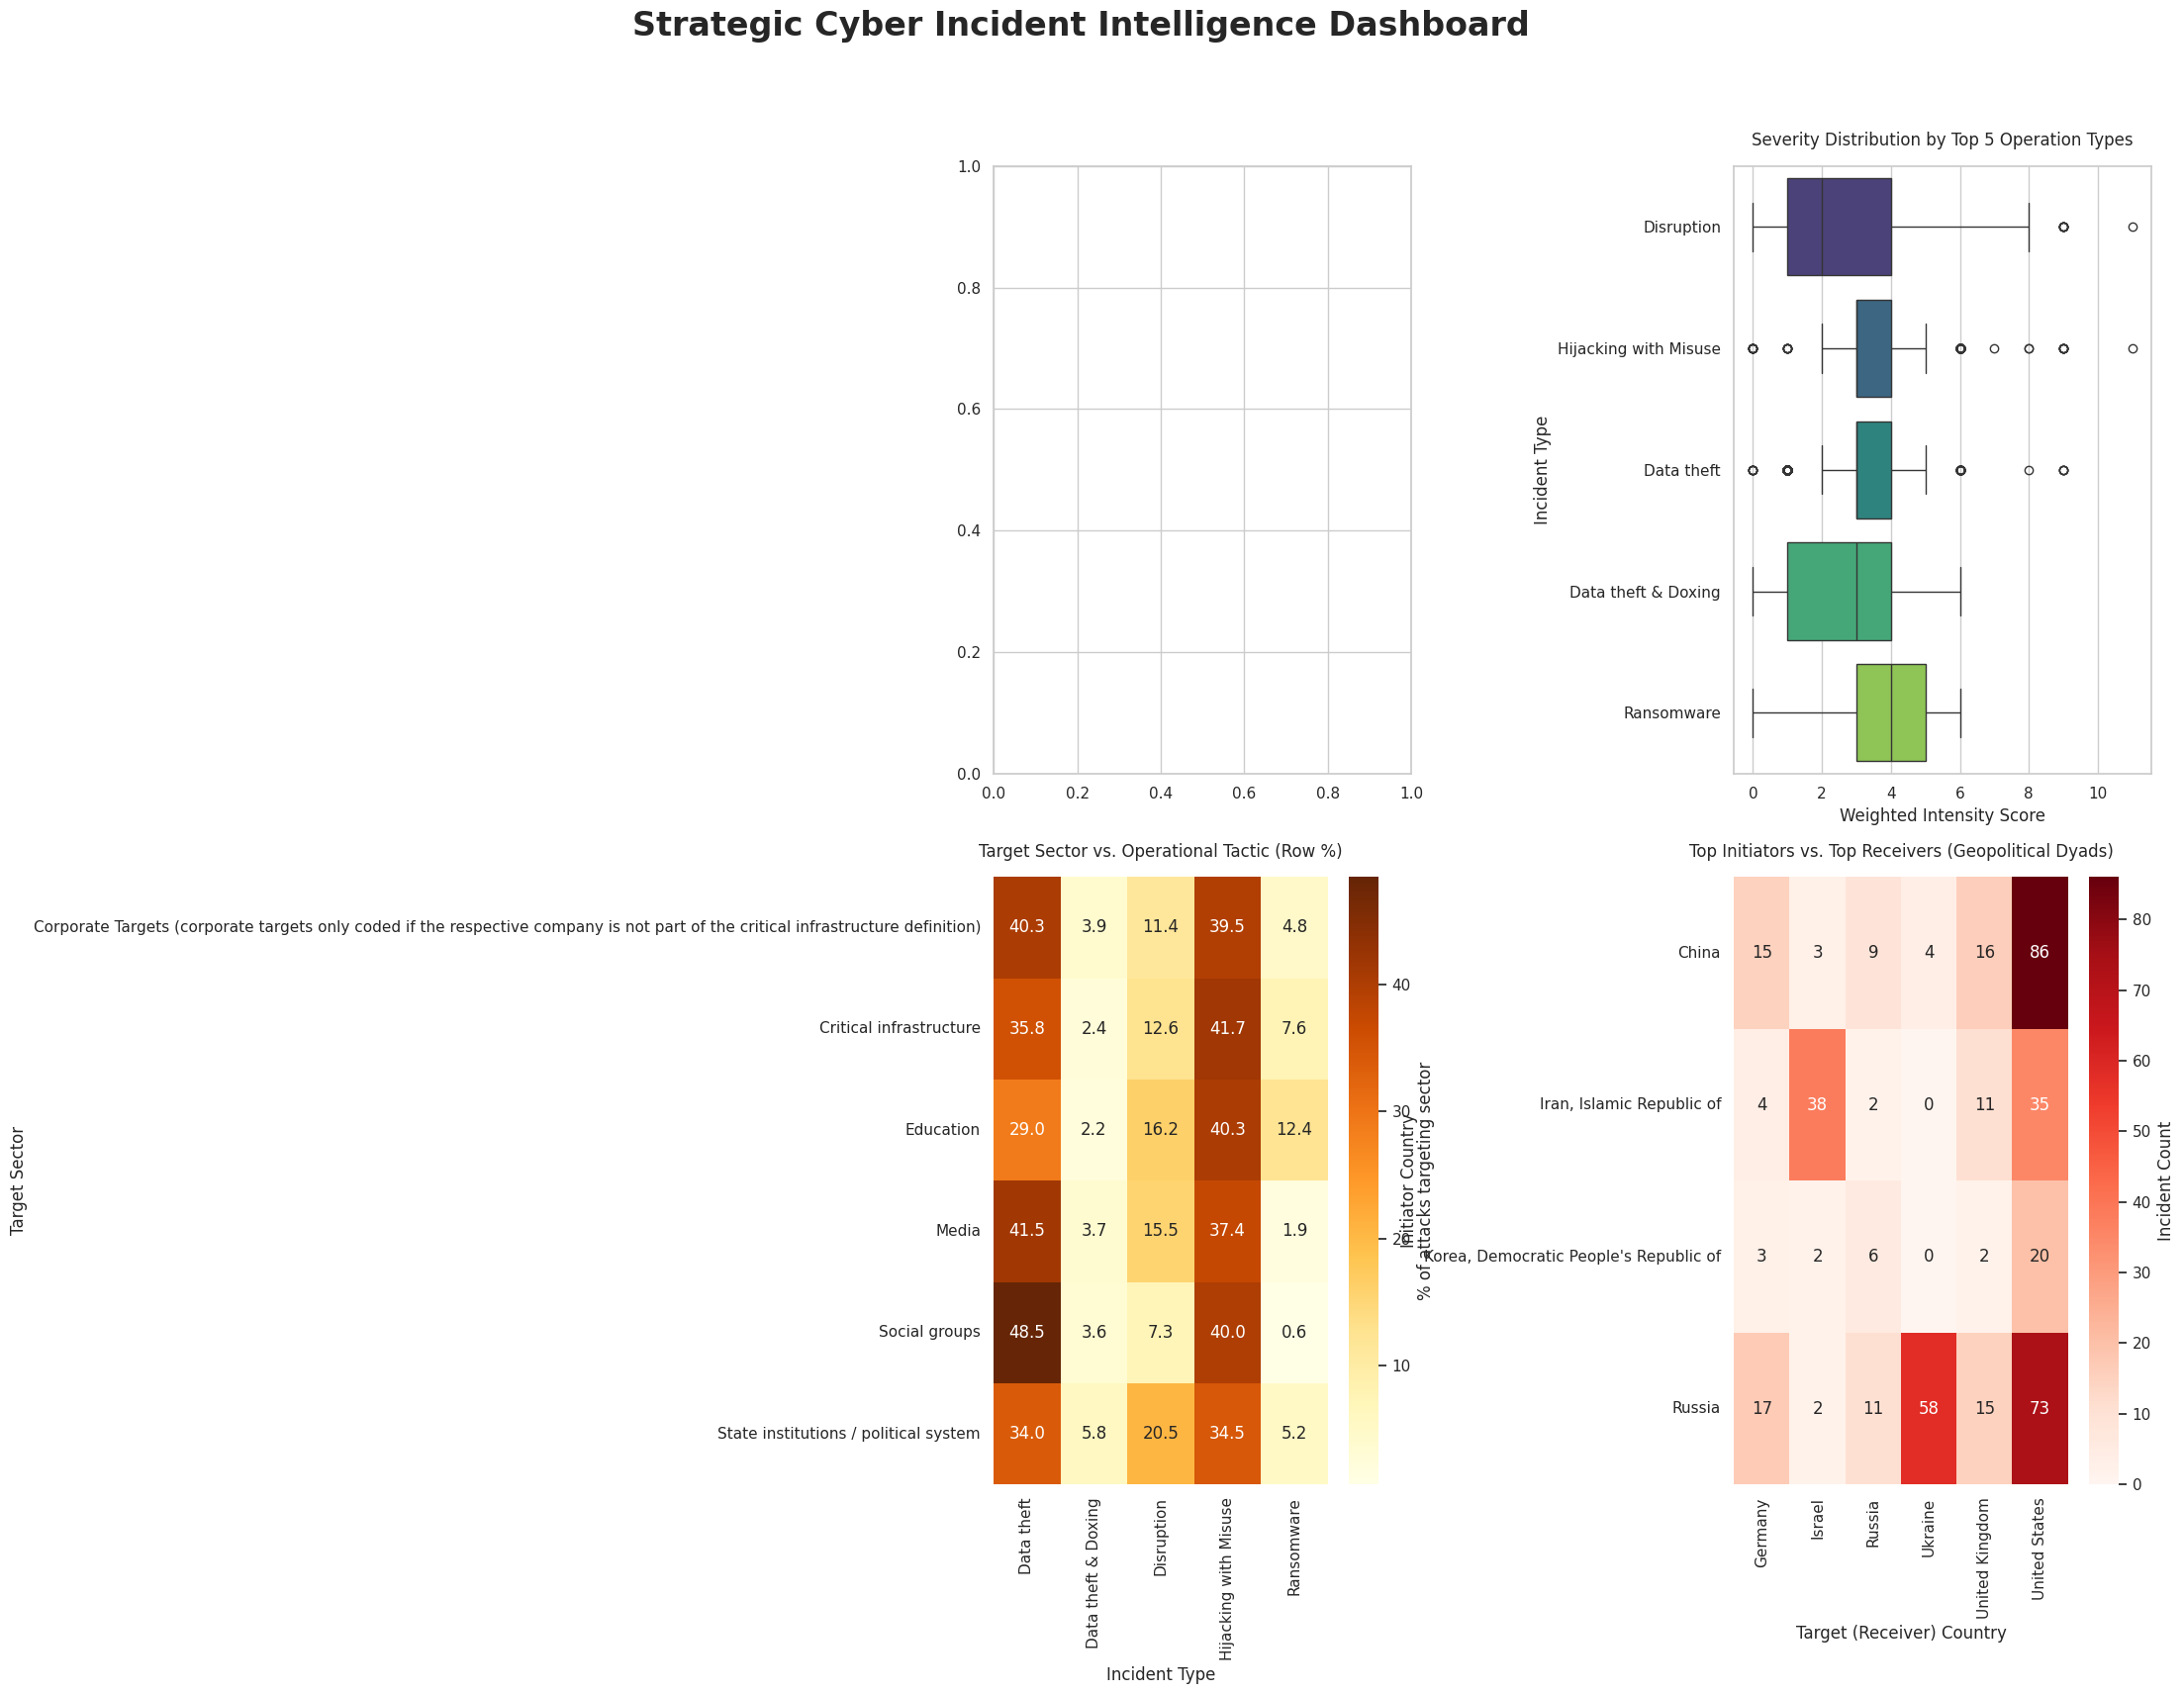

In [41]:
# ==========================================
# 3. MULTI-DIMENSIONAL EDA
# ==========================================
print("\n--- Generating Multi-Dimensional Visualizations ---")

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle('Strategic Cyber Incident Intelligence Dashboard', fontsize=24, weight='bold', y=0.98)


# Plot 1: Intensity Distribution by Top Incident Types
# Compares severity across different tactics (e.g., Disruption vs. Data Theft)
if not exploded_types.empty:
    sns.boxplot(
        data=exploded_types[exploded_types['incident_type_list'].isin(top_types)],
        y='incident_type_list', x='weighted_intensity',
        ax=axes[0, 1], palette='viridis'
    )
    axes[0, 1].set_title('Severity Distribution by Top 5 Operation Types', pad=15)
    axes[0, 1].set_ylabel('Incident Type')
    axes[0, 1].set_xlabel('Weighted Intensity Score')

# Plot 2: Target Sector vs Attack Type Heatmap (Probabilities)
# Identifies which sectors are targeted by specific types of attacks[cite: 1]
merged_sector_type = exploded_types.explode('receiver_category_list').reset_index(drop=True).dropna(subset=['receiver_category_list'])
if not merged_sector_type.empty:
    top_sectors = merged_sector_type['receiver_category_list'].value_counts().nlargest(6).index
    ct_sector_type = pd.crosstab(
        merged_sector_type[merged_sector_type['receiver_category_list'].isin(top_sectors)]['receiver_category_list'],
        merged_sector_type[merged_sector_type['incident_type_list'].isin(top_types)]['incident_type_list'],
        normalize='index' # Row-wise normalization yields percentages
    ) * 100
    sns.heatmap(ct_sector_type, annot=True, fmt=".1f", cmap="YlOrBr", ax=axes[1, 0], cbar_kws={'label': '% of attacks targeting sector'})
    axes[1, 0].set_title('Target Sector vs. Operational Tactic (Row %)', pad=15)
    axes[1, 0].set_ylabel('Target Sector')
    axes[1, 0].set_xlabel('Incident Type')

# Plot 3: The Geopolitical Fault Lines (Top Initiators vs Top Receivers)
# Highlights the massive asymmetry, particularly targeting the US[cite: 1]
top_initiators = ['Russia', 'China', "Korea, Democratic People's Republic of", 'Iran, Islamic Republic of']
top_receivers = ['United States', 'Russia', 'Germany', 'United Kingdom', 'Ukraine', 'Israel']
if not dyadic_df.empty:
    dyad_heatmap = pd.crosstab(
        dyadic_df[dyadic_df['initiator_country'].isin(top_initiators)]['initiator_country'],
        dyadic_df[dyadic_df['receiver_country'].isin(top_receivers)]['receiver_country']
    )
    sns.heatmap(dyad_heatmap, annot=True, fmt="d", cmap="Reds", ax=axes[1, 1], cbar_kws={'label': 'Incident Count'})
    axes[1, 1].set_title('Top Initiators vs. Top Receivers (Geopolitical Dyads)', pad=15)
    axes[1, 1].set_ylabel('Initiator Country')
    axes[1, 1].set_xlabel('Target (Receiver) Country')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [34]:
# ==========================================
# 4. STATISTICAL MODELING
# ==========================================
print("--- STATISTICAL ANALYSIS RESULTS ---")

# 4.1 Logistic Regression: Intensity vs. Political Response
# Drop NaNs for the regression
logit_df = global_df[['has_political_response', 'weighted_intensity']].dropna()
X = sm.add_constant(logit_df['weighted_intensity'])
y = logit_df['has_political_response']

logit_model = sm.Logit(y, X).fit(disp=0)
print("\n[Model 1] Logistic Regression: Probability of Political Response given Intensity")
print(logit_model.summary().tables[1])

# Calculate Odds Ratio
beta_1 = logit_model.params['weighted_intensity']
print(f"Odds Ratio for Intensity: {np.exp(beta_1):.3f}")
print("Interpretation: A 1-unit increase in intensity score barely moves the needle on the odds of a political response.")

# Hypothesis 1: Does incident severity (weighted_intensity) differ significantly by Incident Type?
# Since intensity is ordinal/skewed, we use the non-parametric Kruskal-Wallis H-test.
exploded_types = global_df.explode('incident_type_list').dropna(subset=['incident_type_list', 'weighted_intensity'])

groups = []
types = exploded_types['incident_type_list'].unique()
for t in types:
    groups.append(exploded_types[exploded_types['incident_type_list'] == t]['weighted_intensity'].values)

stat, p_val_kw = kruskal(*groups)
print(f"Kruskal-Wallis Test (Severity by Incident Type):")
print(f"H-statistic: {stat:.2f}, P-value: {p_val_kw:.4e}")
if p_val_kw < 0.05:
    print("-> Result: Significant difference in severity scores across different operation types.\n")

# Hypothesis 2: Do different top state actors prefer different attack types?
# (Testing association between Initiator Country and Incident Type using Chi-Square)
top_initiators = ['Russia', 'China', 'Korea, Democratic People\'s Republic of', 'Iran, Islamic Republic of']
chi_df = exploded_types.explode('initiator_country_list')
chi_df = chi_df[chi_df['initiator_country_list'].isin(top_initiators)]
contingency_table = pd.crosstab(chi_df['initiator_country_list'], chi_df['incident_type_list'])

chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Test (Actor vs. Attack Type):")
print(f"Chi2: {chi2:.2f}, P-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("-> Result: State actors exhibit statistically significant preferences for specific operational tactics.\n")

# Hypothesis 3: Does higher severity guarantee a higher number of political/legal responses?
# Using Spearman rank correlation due to skewed numeric distributions.
response_cols = ['weighted_intensity', 'number_political_responses', 'number_legal_responses']
corr_df = global_df[response_cols].fillna(0)

corr_coef, p_val_corr = spearmanr(corr_df['weighted_intensity'], corr_df['number_political_responses'])
print(f"Spearman Correlation (Intensity vs Political Responses):")
print(f"Correlation Coefficient: {corr_coef:.3f}, P-value: {p_val_corr:.4e}")
if corr_coef < 0.3:
    print("-> Result: Very weak correlation. A highly destructive attack does NOT statistically guarantee a formal political response.")

--- STATISTICAL ANALYSIS RESULTS ---

[Model 1] Logistic Regression: Probability of Political Response given Intensity
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.7460      0.125    -22.036      0.000      -2.990      -2.502
weighted_intensity     0.1575      0.040      3.930      0.000       0.079       0.236
Odds Ratio for Intensity: 1.171
Interpretation: A 1-unit increase in intensity score barely moves the needle on the odds of a political response.
Kruskal-Wallis Test (Severity by Incident Type):
H-statistic: 1166.09, P-value: 1.0464e-248
-> Result: Significant difference in severity scores across different operation types.

Chi-Square Test (Actor vs. Attack Type):
Chi2: 362.22, P-value: 6.6455e-66
-> Result: State actors exhibit statistically significant preferences for specific operational tactics.

Spearman Correlation (Inten

In [38]:
# ==========================================
# 4. STATISTICAL MODELING & HYPOTHESIS TESTING
# ==========================================
print("\n--- STATISTICAL ANALYSIS RESULTS ---")

# Hypothesis 1: Does incident severity predict a formal political response?
# Model: Logistic Regression
# We model the binary 'has_political_response' against the continuous 'weighted_intensity'.
logit_df = global_df[['has_political_response', 'weighted_intensity']].dropna()

if not logit_df.empty and len(logit_df['has_political_response'].unique()) > 1:
    X = sm.add_constant(logit_df['weighted_intensity'])
    y = logit_df['has_political_response']
    try:
        logit_model = sm.Logit(y, X).fit(disp=0)
        print("\n[Model 1] Logistic Regression: Probability of Political Response given Intensity")
        print(logit_model.summary().tables[1])

        # Calculate Odds Ratio
        beta_1 = logit_model.params['weighted_intensity']
        odds_ratio = np.exp(beta_1)
        p_value = logit_model.pvalues['weighted_intensity']
        print(f"Odds Ratio for Intensity: {odds_ratio:.3f}")

        if p_value > 0.05:
            print("Interpretation: The p-value indicates this relationship is NOT statistically significant. High severity does NOT reliably predict a political response.")
        else:
             print("Interpretation: While statistically significant, check the odds ratio. If it is close to 1, severity barely moves the needle on predicting a response.")
    except Exception as e:
        print(f"Could not fit Logistic Regression: {e}")
else:
    print("\n[Model 1] Insufficient data to run Logistic Regression.")


# Hypothesis 2: Is incident severity fundamentally different across attack types?
# Model: Kruskal-Wallis H-Test (Non-parametric ANOVA equivalent)
# We test if median severity differs significantly between the top 5 incident types.
kruskal_groups = []
for t in top_types:
    group_data = exploded_types[exploded_types['incident_type_list'] == t]['weighted_intensity'].dropna().values
    if len(group_data) > 0:
        kruskal_groups.append(group_data)

if len(kruskal_groups) > 1:
    h_stat, p_val_kw = kruskal(*kruskal_groups)
    print("\n[Model 2] Kruskal-Wallis H-Test: Variance in Severity by Attack Type")
    print(f"H-Statistic: {h_stat:.3f}, P-Value: {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print("Interpretation: H0 Rejected. The operational tactic chosen fundamentally dictates the statistical severity of the attack.")
    else:
        print("Interpretation: Fail to reject H0. No significant difference in median severity across attack types.")
else:
     print("\n[Model 2] Insufficient data groups to run Kruskal-Wallis Test.")


# Hypothesis 3: Do specific state actors exhibit significant preferences for certain attack types?
# Model: Chi-Square Test of Independence
chi_df = exploded_types.explode('initiator_country_list').dropna(subset=['initiator_country_list', 'incident_type_list'])
chi_df = chi_df[chi_df['initiator_country_list'].isin(top_initiators)]

if not chi_df.empty:
    contingency_table = pd.crosstab(chi_df['initiator_country_list'], chi_df['incident_type_list'])
    chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)
    print("\n[Model 3] Chi-Square Test: Association between Initiator Country and Attack Type")
    print(f"Chi2 Statistic: {chi2:.3f}, P-Value: {p_val_chi:.4e}")
    if p_val_chi < 0.05:
         print("Interpretation: H0 Rejected. Top state actors exhibit statistically significant, distinct preferences for specific operational tactics.")
    else:
         print("Interpretation: Fail to reject H0. No significant association found.")
else:
     print("\n[Model 3] Insufficient data to run Chi-Square Test.")


# Hypothesis 4: Does higher severity guarantee a higher number of political/legal responses?
# Using Spearman rank correlation due to skewed numeric distributions.
response_cols = ['weighted_intensity', 'number_political_responses', 'number_legal_responses']
corr_df = global_df[response_cols].fillna(0)

corr_coef, p_val_corr = spearmanr(corr_df['weighted_intensity'], corr_df['number_political_responses'])
print("\n[Model 4]")
print(f"Spearman Correlation (Intensity vs Political Responses):")
print(f"Correlation Coefficient: {corr_coef:.3f}, P-value: {p_val_corr:.4e}")
if corr_coef < 0.3:
    print("-> Result: Very weak correlation. A highly destructive attack does NOT statistically guarantee a formal political response.")


--- STATISTICAL ANALYSIS RESULTS ---

[Model 1] Logistic Regression: Probability of Political Response given Intensity
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.7460      0.125    -22.036      0.000      -2.990      -2.502
weighted_intensity     0.1575      0.040      3.930      0.000       0.079       0.236
Odds Ratio for Intensity: 1.171
Interpretation: While statistically significant, check the odds ratio. If it is close to 1, severity barely moves the needle on predicting a response.

[Model 2] Kruskal-Wallis H-Test: Variance in Severity by Attack Type
H-Statistic: 582.484, P-Value: 9.5725e-125
Interpretation: H0 Rejected. The operational tactic chosen fundamentally dictates the statistical severity of the attack.

[Model 3] Chi-Square Test: Association between Initiator Country and Attack Type
Chi2 Statistic: 362.220, P-Value

In [35]:
from ydata_profiling import ProfileReport

# Generate the profile report from the encoded dataset
receiver_profile = ProfileReport(receiver_df , title="Cybersecurity_Threat_receiver_EDA_Report", explorative=True)

# Export it to HTML (download this manually in Colab after rendering)
receiver_profile.to_file("cybersecurity_threat_receiver_eda_report.html")

# Generate the profile report from the encoded dataset
dyadic_profile = ProfileReport(dyadic_df , title="Cybersecurity_Threat_dyadic_EDA_Report", explorative=True)

# Export it to HTML (download this manually in Colab after rendering)
dyadic_profile.to_file("cybersecurity_threat_dyadic_eda_report.html")

# Generate the profile report from the encoded dataset
attribution_profile = ProfileReport(attribution_df , title="Cybersecurity_Threat_attribution_EDA_Report", explorative=True)

# Export it to HTML (download this manually in Colab after rendering)
attribution_profile.to_file("cybersecurity_threat_attribution_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 13.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:00<00:00, 26.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]